In [1]:
import pandas as pd 
import sys 
sys.path.append("/workspace/")
from src.metrics import ClinicalQAEvaluator
from glob import glob  

# result_root_dir = "/workspace/kor_med_opendataset/results/snuh_ClinicalQA_benchmark" # ClinicalQA
result_root_dir = "/workspace/kor_med_opendataset/results/sean0042_KorMedMCQA_benchmark/doctor" # KorMedMCQA

In [2]:
from IPython.display import display
import os 
parquet_files = glob(f"{result_root_dir}/**/*.parquet", recursive=False)

all_summary_df = pd.DataFrame()
for parquet_file in parquet_files:
    model_name = parquet_file.split('/')[-2]
    evaluator = ClinicalQAEvaluator(parquet_file)

    # 성능 요약
    summary_df = evaluator.summary()
    
    # 맨 앞에 모델명 붙히기
    summary_df.insert(0, 'model', model_name)
    
    all_summary_df = pd.concat([all_summary_df, summary_df])
    
all_summary_df = all_summary_df.sort_values("accuracy (%)", ascending=True)
# all_summary_df.to_csv(f"{result_root_dir}/all_summary.csv", index=False)


In [3]:
# 모델명을 '_'로 분리해 그룹(시리즈)와 이름을 분리해서, 시리즈(group)별로 accuracy 오름차순 정렬해서 보여주기
df_temp = all_summary_df.copy()
df_temp['model_group'] = df_temp['model'].apply(lambda x: x.split('_')[0])
df_temp['model_name'] = df_temp['model'].apply(lambda x: '_'.join(x.split('_')[1:]))

df_temp['mean_flops (GFlops)'] = (df_temp['mean_flops'] / 1e9).round(3)
df_temp['accuracy (%)'] = df_temp['accuracy (%)'].round(3)
df_temp['avg_time_per_token (s)'] = df_temp['avg_time_per_token (s)'].round(3)

display_cols = ['model_group', 'model_name', 'accuracy (%)', 'avg_time_per_token (s)', 'mean_flops (GFlops)']
# model_group별로 accuracy 오름차순 정렬
df_temp = df_temp.sort_values(['model_group', 'accuracy (%)'], ascending=[True, True])
display(df_temp[display_cols])

,model_group,model_name,accuracy (%),avg_time_per_token (s),mean_flops (GFlops)
0,LGAI-EXAONE,EXAONE-3_5-2_4B-Instruct,40.27,0.009,288.622
0,LGAI-EXAONE,EXAONE-4_0-1_2B,42.86,0.011,153.495
0,LGAI-EXAONE,EXAONE-3_5-7_8B-Instruct,50.70,0.020,938.235
0,Qwen,Qwen3-0_6B,28.13,0.010,361.690
0,Qwen,Qwen3-1_7B,37.12,0.010,1719.952
0,Qwen,Qwen3-4B-Instruct-2507,53.39,0.015,7851.507
0,Qwen,Qwen3-8B,56.03,0.025,8561.902
0,google,gemma-3-1b-it,24.78,0.020,1310.785
0,google,gemma-3-4b-it,42.35,0.027,5356.819
0,google,medgemma-4b-it,46.36,0.027,5065.830


Looks like you are using a tranform that doesn't support FancyArrowPatch, using ax.annotate instead. The arrows might strike through texts. Increasing shrinkA in arrowprops might help.


Figure saved successfully to: medical_llm_eval.png


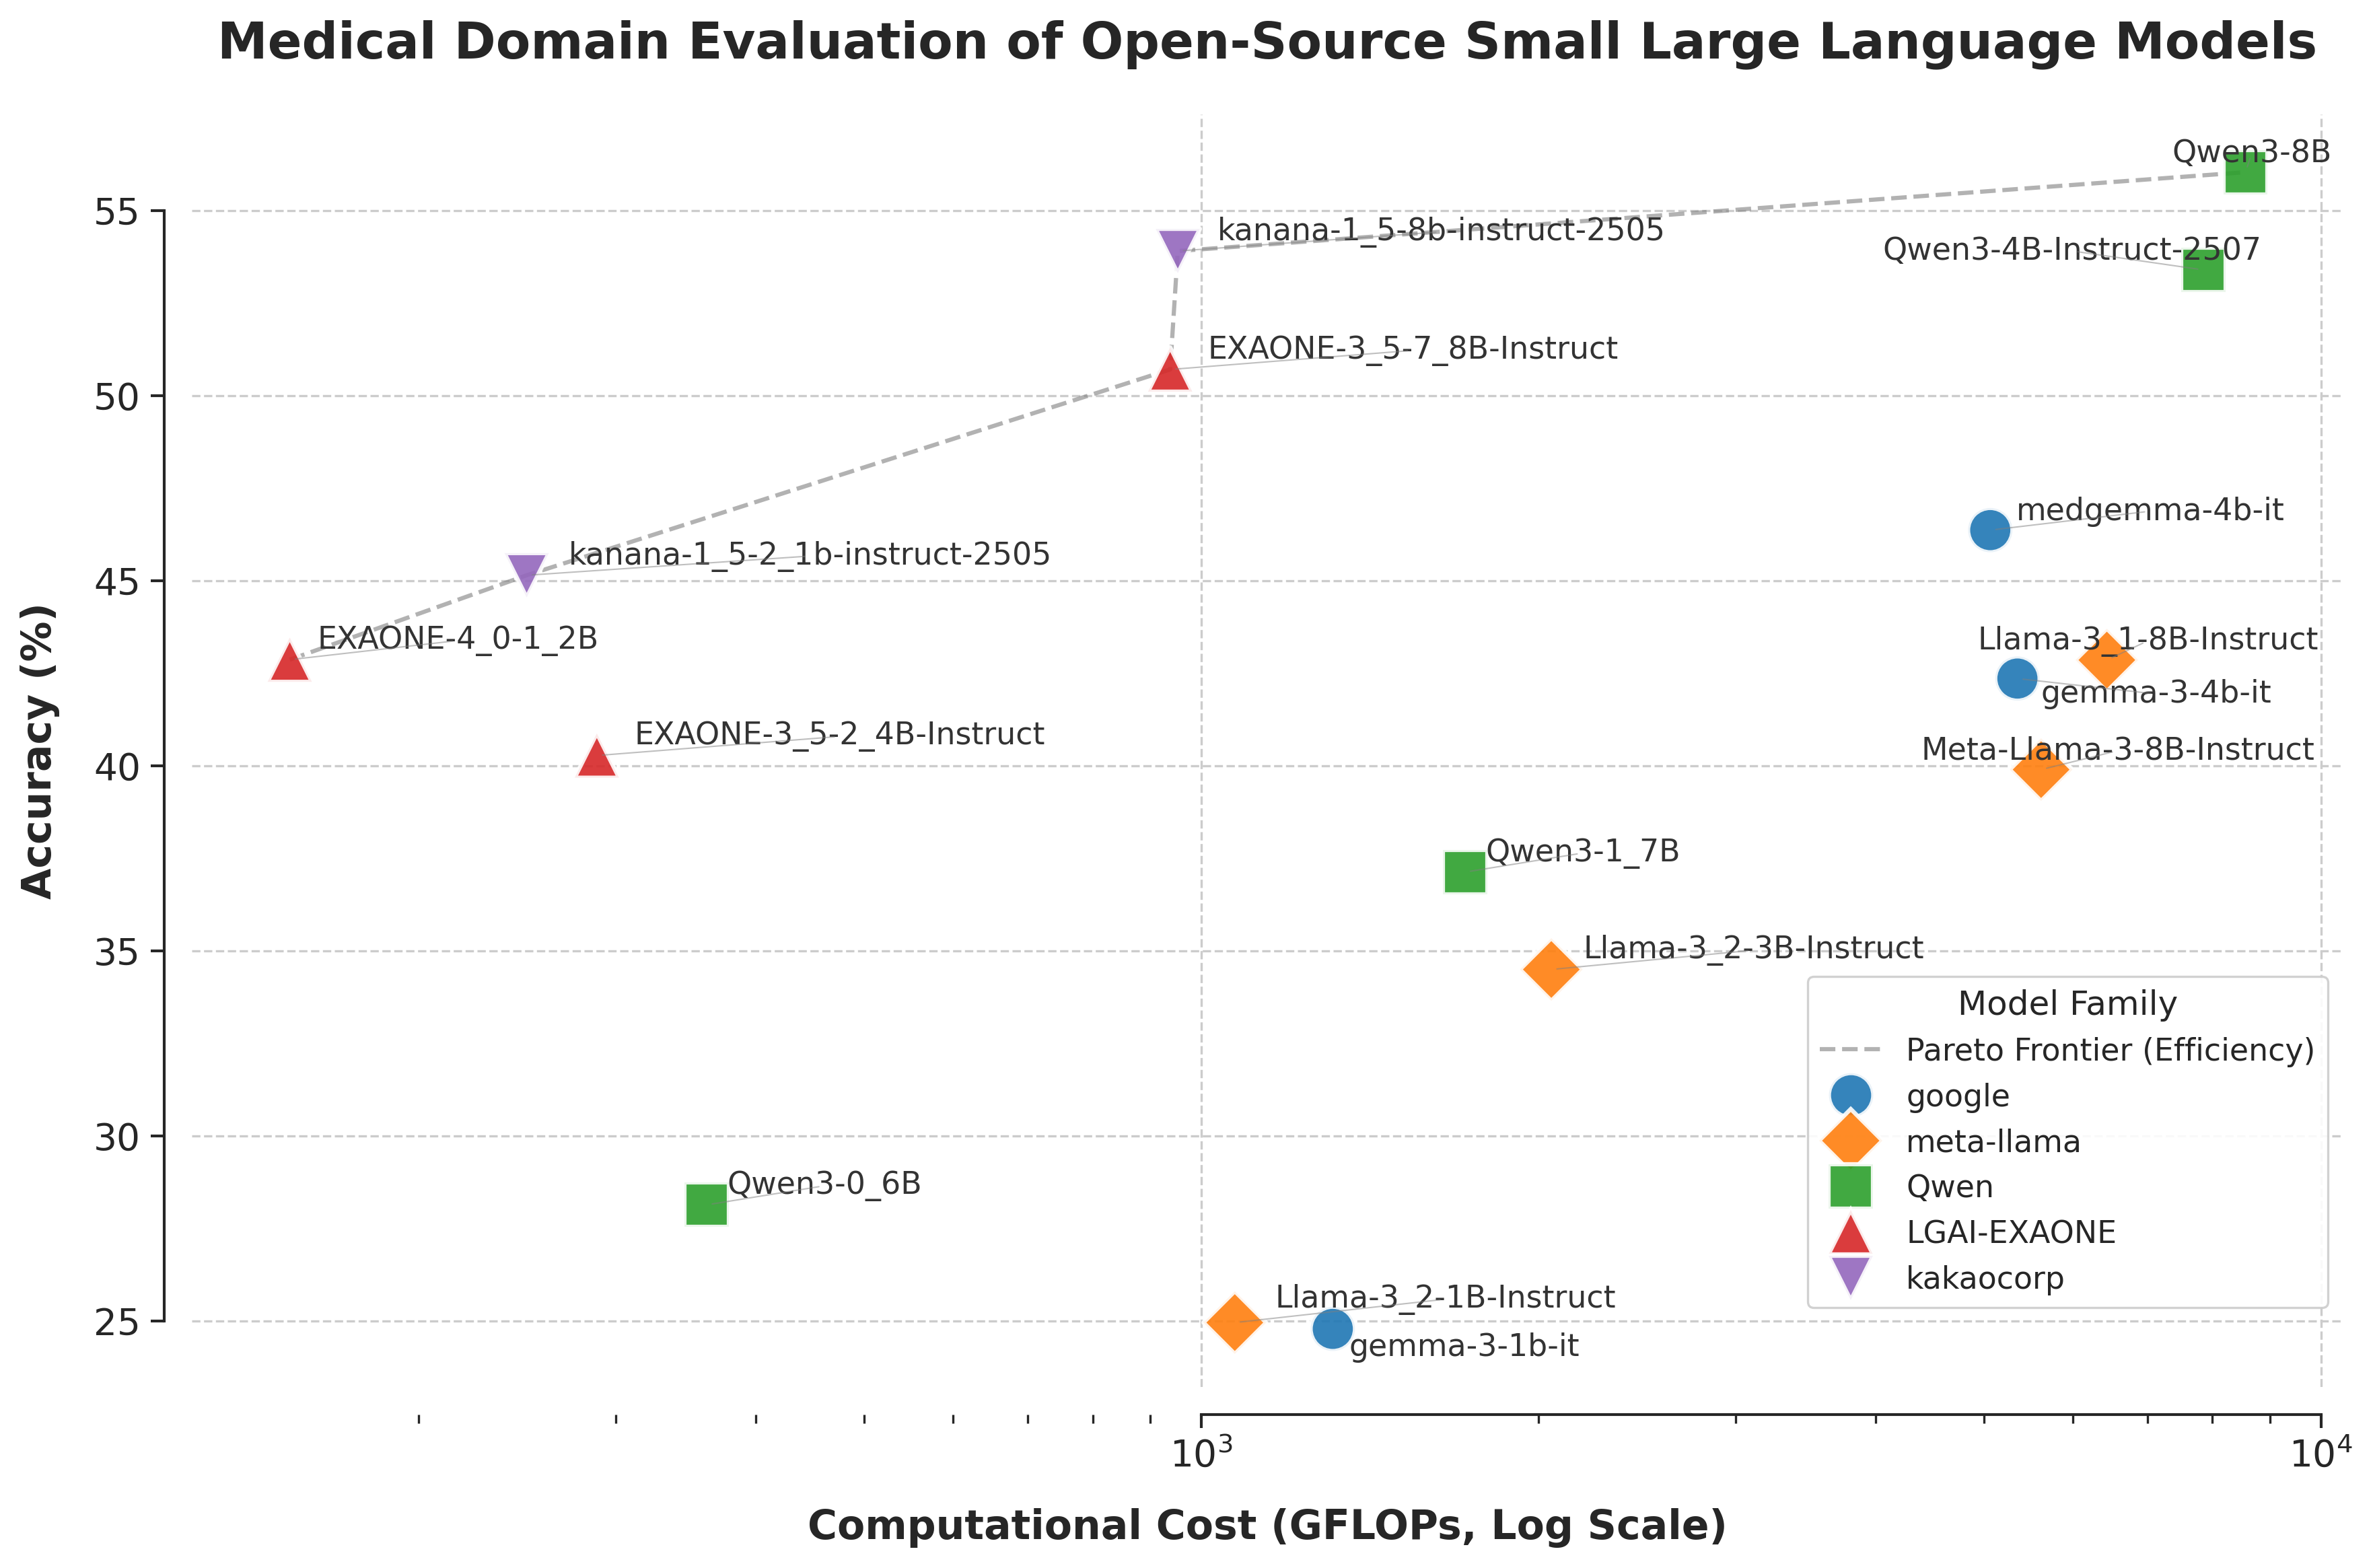

In [4]:
import matplotlib.pyplot as plt
import seaborn as sns
import pandas as pd
import numpy as np

# ---------------------------------------------------------
# 1. 텍스트 겹침 방지 라이브러리 확인 (없으면 기본 텍스트 사용)
# ---------------------------------------------------------
try:
    from adjustText import adjust_text
    HAS_ADJUST_TEXT = True
except ImportError:
    HAS_ADJUST_TEXT = False
    print("Tip: 'pip install adjustText'를 하면 라벨이 겹치지 않게 자동 정렬됩니다.")

# ---------------------------------------------------------
# 2. 논문용 고품질 플롯 함수 정의
# ---------------------------------------------------------
def plot_medical_llm_benchmark(
    df,
    x_col='mean_flops',
    y_col='accuracy (%)',
    model_col='model',
    figsize=(12, 8),  # 논문용으로 시원한 크기
    dpi=300,
    title="Medical Domain Evaluation of Open-Source Small Large Language Models",
    save_path="medical_llm_eval.png"
):
    # 데이터 전처리: 그룹명과 모델 짧은 이름 추출
    plot_df = df.copy()
    
    # -------------------------------------------------------
    # [수정됨] FLOPs 단위를 GFLOPs로 변환 (1 GFLOPs = 1e9 FLOPs)
    # -------------------------------------------------------
    plot_df[x_col] = plot_df[x_col] / 1e9
    
    # 예: 'Llama-2_7B' -> Group: 'Llama-2', Short: '7B'
    plot_df['Group'] = plot_df[model_col].apply(lambda x: x.split('_')[0])
    plot_df['Short Name'] = plot_df[model_col].apply(lambda x: '_'.join(x.split('_')[1:]))

    # Seaborn 스타일 설정 (논문 스타일: 깔끔한 흰색 배경, 틱 강조)
    sns.set_context("paper", font_scale=1.5)
    sns.set_style("ticks", {'axes.grid': True, 'grid.linestyle': '--', 'grid.alpha': 0.5})

    fig, ax = plt.subplots(figsize=figsize, dpi=dpi)

    # -------------------------------------------------------
    # A. Pareto Frontier (효율성 경계선) 그리기
    # -------------------------------------------------------
    # X축(연산량) 정렬 후, 현재까지의 최대 정확도를 가진 점들을 연결
    sorted_df = plot_df.sort_values(by=x_col)
    pareto_points = []
    current_max_y = -np.inf
    
    for _, row in sorted_df.iterrows():
        if row[y_col] > current_max_y:
            pareto_points.append((row[x_col], row[y_col]))
            current_max_y = row[y_col]
            
    if pareto_points:
        px, py = zip(*pareto_points)
        ax.plot(px, py, color='gray', linestyle='--', linewidth=1.5, alpha=0.6, zorder=1, label='Pareto Frontier (Efficiency)')

    # -------------------------------------------------------
    # B. 메인 산점도 (Scatter Plot)
    # -------------------------------------------------------
    # 마커 모양 리스트 (그룹별로 모양을 다르게 하여 흑백 인쇄 시에도 구분 가능)
    markers = ['o', 'D', 's', '^', 'v', 'X', 'P', '*', 'h', '<']
    unique_groups = plot_df['Group'].unique()
    marker_map = {g: markers[i % len(markers)] for i, g in enumerate(unique_groups)}

    sns.scatterplot(
        data=plot_df,
        x=x_col,
        y=y_col,
        hue='Group',
        style='Group',
        markers=marker_map,
        palette='tab10',  # 명확한 색상 구분
        s=250,            # 마커 크기 확대
        alpha=0.9,
        edgecolor='white',
        linewidth=1.5,
        ax=ax,
        zorder=3
    )

    # -------------------------------------------------------
    # C. 축 및 타이틀 설정
    # -------------------------------------------------------
    ax.set_xscale('log')
    # [수정됨] X축 라벨 변경 (GFLOPs)
    ax.set_xlabel("Computational Cost (GFLOPs, Log Scale)", fontweight='bold', labelpad=12)
    ax.set_ylabel("Accuracy (%)", fontweight='bold', labelpad=12)
    
    if title:
        ax.set_title(title, fontweight='bold', fontsize=18, pad=20)

    # 테두리 정리 (오른쪽, 위쪽 테두리 제거 - Tufte 스타일)
    sns.despine(trim=True, offset=10)

    # -------------------------------------------------------
    # D. 라벨링 (adjustText 사용 권장)
    # -------------------------------------------------------
    texts = []
    for _, row in plot_df.iterrows():
        texts.append(
            ax.text(
                row[x_col], 
                row[y_col], 
                row['Short Name'], 
                fontsize=11, 
                color='#333333',
                fontweight='medium'
            )
        )

    if HAS_ADJUST_TEXT:
        # 화살표 색상을 회색으로 은은하게 처리
        adjust_text(
            texts, 
            ax=ax,
            arrowprops=dict(arrowstyle='-', color='gray', alpha=0.5, lw=0.5),
            expand_points=(1.2, 1.2),
            force_text=(0.3, 0.5)
        )

    # -------------------------------------------------------
    # E. 범례 (Legend) 최적화
    # -------------------------------------------------------
    # 범례를 그래프 안쪽(우측 하단)에 배치하되, 반투명 박스로 처리
    ax.legend(
        title="Model Family",
        loc='lower right',
        bbox_to_anchor=(1.0, 0.05),
        frameon=True,
        fancybox=True,
        framealpha=0.9,
        edgecolor='0.8',
        fontsize=11,
        title_fontsize=12
    )

    plt.tight_layout()
    
    if save_path:
        plt.savefig(save_path, dpi=dpi, bbox_inches='tight')
        print(f"Figure saved successfully to: {save_path}")

    plt.show()

plot_medical_llm_benchmark(all_summary_df)

In [5]:
import pandas as pd 


df = pd.read_parquet("/workspace/kor_med_opendataset/results/sean0042_KorMedMCQA_benchmark/doctor/google_gemma-3-1b-it/google_gemma-3-1b-it_detailed.parquet")
df

,question_id,gt_answer,pred_answer,pred_explanation,first_token_latency_s,time_per_token_s,vram_used_MB,flops_this,flops_per_token,cost_per_token_s
0,광역시 소재 대학병원에 소속된 내과 전문의 A가 콜레라 환자를 진단했다. A가 할 ...,1,3,콜레라 환자를 진단한 내과 전문의 A는 해당 환자를 지역 사회로 확산시키는 것을 막...,4.611128,0.029945,92.0,923894619648,5999315712,0.029945
1,A는 제1급 감염병으로 진단을 받았다. B는 마스크를 착용하지 않은 채 A와 밀접하...,3,3,B는 마스크를 착용하지 않은 채 A와 밀접하게 접촉했다는 사실은 B가 감염병의 전파...,3.775105,0.030694,92.0,737915832576,5999315712,0.030694
2,검역소 내 격리병동에 격리되어 있던 콜레라 환자 A의 감염력이 없어진 것이 확인되었...,1,1,콜레라 환자 A의 감염력이 없어진 것은 중요한 정보입니다. 감염력이 없어진다는 것은...,1.584635,0.017808,92.0,533939098368,5999315712,0.017808
3,A 의원 B 원장은 요양급여비용 지급과 관련된 국민건강보험공단의 처분에 대해 이의신...,4,4,건강보험분쟁조정위원회는 국민건강보험공단과 국민건강보험심사평가원 간의 분쟁을 조정하는...,1.834120,0.016527,92.0,665924044032,5999315712,0.016527
4,종합병원의 병원장이 적법하게 흡연실을 설치할 수 있는 방법은?,2,1,종합병원의 병원장이 적법하게 흡연실을 설치하기 위해서는 병원 한 개 층 전체를 흡연...,8.596171,0.028655,98.0,1799794713600,5999315712,0.028655
...,...,...,...,...,...,...,...,...,...,...
2481,56세 남자가 2일 전부터 엉뚱한 말을 한다며 보호자와 함께 병원에 왔다. 5년 전...,2,3,환자의 증상과 신경학적 검사 결과는 두정엽의 문제와 가장 관련이 있습니다. 두정엽은...,3.145439,0.015969,122.0,1181865195264,5999315712,0.015969
2482,31세 여자가 6년 전부터 자주 발생하는 두통으로 병원에 왔다. 오른쪽 옆머리에 욱...,4,2,"주어진 증상(6년 전부터 자주 발생하는 두통, 오른쪽 옆머리 욱신욱신 쑤심, 일상생...",2.408164,0.013306,122.0,1085876143872,5999315712,0.013306
2483,18세 여자가 3년 전부터 자주 놀라고 멍해진다며 보호자와 함께 병원에 왔다. 주로...,5,1,"환자의 증상 - 자주 놀리고 멍해짐, 잠 부족 후 갑작스러운 스마트폰 놓기, 순간적...",3.982926,0.018441,122.0,1295852193792,5999315712,0.018441
2484,62세 남자가 30분 전부터 오른족 팔다리가 마비되어 병원에 왔다. 3년 전부터 고...,3,1,"환자의 증상(오른족 팔다리 마비, 의식 저하, 근력저하, MRC척도 2/5)은 뇌졸...",2.460844,0.013022,122.0,1133870669568,5999315712,0.013022


In [6]:
all_summary_df

,model,total_samples,correct_predictions,accuracy (%),avg_first_token_latency (s),avg_time_per_token (s),avg_vram_usage (MB),mean_flops,mean_flops_per_token,mean_cost_per_token (s)
0,google_gemma-3-1b-it,2486,616,24.78,4.511110,0.020480,120.238134,1.310785e+12,5.999316e+09,0.020480
0,meta-llama_Llama-3_2-1B-Instruct,2212,552,24.95,0.797072,0.005782,16523.767518,1.071578e+12,7.414886e+09,0.005782
0,Qwen_Qwen3-0_6B,2485,699,28.13,0.953115,0.009537,370.361368,3.616898e+11,3.576300e+09,0.009537
0,meta-llama_Llama-3_2-3B-Instruct,2299,793,34.49,1.086057,0.010564,1796.471781,2.054402e+12,1.927650e+10,0.010564
0,Qwen_Qwen3-1_7B,2484,922,37.12,1.727224,0.010406,-37.004831,1.719952e+12,1.032345e+10,0.010406
0,meta-llama_Meta-Llama-3-8B-Instruct,2477,988,39.89,2.297449,0.019722,193.657297,5.624172e+12,4.818157e+10,0.019722
0,LGAI-EXAONE_EXAONE-3_5-2_4B-Instruct,2436,981,40.27,0.185497,0.009288,1476.865353,2.886215e+11,1.443196e+10,0.009288
0,google_gemma-3-4b-it,2484,1052,42.35,5.508054,0.026603,356.017713,5.356819e+12,2.580048e+10,0.026603
0,meta-llama_Llama-3_1-8B-Instruct,2483,1064,42.85,2.621464,0.019672,403.344845,6.438361e+12,4.818157e+10,0.019672
0,LGAI-EXAONE_EXAONE-4_0-1_2B,2382,1021,42.86,0.214723,0.010750,-156.076931,1.534948e+11,7.676349e+09,0.010750


In [7]:
from IPython.display import display
import json
js_files = glob(f"{result_root_dir}/**/*.json", recursive=False)

js_dict = {}
for js_file in js_files:
    model_name = js_file.split('/')[-2]
    with open(js_file, 'r') as f:
        js_dict[model_name] = json.load(f)
import pandas as pd

def seconds_to_hms(seconds):
    """Convert seconds to HH:MM:SS format"""
    seconds = int(seconds)
    hours = seconds // 3600
    minutes = (seconds % 3600) // 60
    sec = seconds % 60
    return f"{hours:02}:{minutes:02}:{sec:02}"

# Transform dict into list of dicts for DataFrame construction
records = []
for key, v in js_dict.items():
    rec = dict(model_group=key)
    rec.update(v)
    rec['total_time_hms'] = seconds_to_hms(v['total_time_s'])
    records.append(rec)

df = pd.DataFrame(records)

# Move total_time_hms next to total_time_s
if 'total_time_s' in df.columns and 'total_time_hms' in df.columns:
    cols = list(df.columns)
    time_idx = cols.index('total_time_s')
    cols.insert(time_idx + 1, cols.pop(cols.index('total_time_hms')))
    df = df[cols]

# Display DataFrame as usual
display(df)

# Sum total_time_s and show as HH:MM:SS
if 'total_time_s' in df.columns:
    total_sec = df['total_time_s'].sum()
    total_hms = seconds_to_hms(total_sec)
    print(f"\n전체 모델 total_time_s 합계: {total_sec:.2f}초 → {total_hms} (HH:MM:SS)")

,model_group,model,total_time_s,total_time_hms,throughput_tokens_per_sec,gpu_total_vram_MB,average_vram_used_MB,total_flops,total_tokens,parameters
0,meta-llama_Llama-3_1-8B-Instruct,meta-llama/Llama-3.1-8B-Instruct,6516.348366,01:48:36,50.917474,24564.0,403.344845,15986451366248448,331796,8030261248
1,meta-llama_Meta-Llama-3-8B-Instruct,meta-llama/Meta-Llama-3-8B-Instruct,5805.660053,01:36:45,49.802606,24564.0,193.657297,13931073878777856,289137,8030261248
2,LGAI-EXAONE_EXAONE-3_5-2_4B-Instruct,LGAI-EXAONE/EXAONE-3.5-2.4B-Instruct,462.762410,00:07:42,105.274324,24564.0,1476.865353,703081997982720,48717,2405327360
3,Qwen_Qwen3-0_6B,Qwen/Qwen3-0.6B,2370.452241,00:39:30,106.022385,24564.0,370.361368,898799171665920,251321,596049920
4,google_gemma-3-4b-it,google/gemma-3-4b-it,13693.951162,03:48:13,37.661884,24564.0,356.017713,13306337921335680,515740,4300079472
5,google_gemma-3-1b-it,google/gemma-3-1b-it,11217.724984,03:06:57,48.420157,24564.0,120.238134,3258612319392768,543164,999885952
6,kakaocorp_kanana-1_5-2_1b-instruct-2505,kakaocorp/kanana-1.5-2.1b-instruct-2505,595.528014,00:09:55,53.068872,24564.0,5362.883602,395742387511296,31604,2086984704
7,kakaocorp_kanana-1_5-8b-instruct-2505,kakaocorp/kanana-1.5-8b-instruct-2505,1082.646485,00:18:02,45.419258,24564.0,2193.339903,2369239468941312,49173,8030285824
8,meta-llama_Llama-3_2-3B-Instruct,meta-llama/Llama-3.2-3B-Instruct,2948.378855,00:49:08,83.102278,24564.0,1796.471781,4723069941762048,245017,3212749824
9,Qwen_Qwen3-1_7B,Qwen/Qwen3-1.7B,4295.605696,01:11:35,96.342642,24564.0,-37.004831,4272359722905600,413850,1720574976



전체 모델 total_time_s 합계: 89219.02초 → 24:46:59 (HH:MM:SS)
